In [22]:
import json
import pickle
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pymir import mpl_stylesheet
from pymir import mpl_utils
mpl_stylesheet.banskt_presentation(splinecolor = 'black', dpi = 300)

from matplotlib import colormaps as mpl_cmaps
import matplotlib.colors as mpl_colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [23]:
data_root = "/gpfs/commons/groups/knowles_lab/data/PsychGen/analysis/clorinn/cv_split_replication"
stability_out_dir = f"{data_root}/stability"
summary_out = f"{data_root}/summary/pgd_fw_nnm_stability_metrics.csv"

In [24]:
summary_df = pd.read_csv(summary_out)
summary_df

,nucnorm,mean_dist_k1,mean_dist_k2,mean_dist_k3,mean_dist_k4,mean_dist_k5,mean_dist_k6,mean_dist_k7,mean_dist_k8,mean_dist_k9,...,se_energy_k22,se_energy_k23,se_energy_k24,se_energy_k25,se_energy_k26,se_energy_k27,se_energy_k28,se_energy_k29,se_energy_k30,grid
0,1.0,0.160444,0.707929,0.797938,0.812815,0.819086,0.816190,0.811908,0.790897,0.771676,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,coarse
1,2.0,0.160446,0.708618,0.781608,0.808234,0.811246,0.795547,0.785829,0.768084,0.749795,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,coarse
2,4.0,0.160450,0.702932,0.807883,0.829910,0.823107,0.808503,0.795072,0.784240,0.776822,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,coarse
3,8.0,0.160458,0.704560,0.779610,0.808267,0.777589,0.765466,0.750457,0.730145,0.730250,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,coarse
4,16.0,0.160475,0.711844,0.799948,0.808627,0.802298,0.788015,0.770863,0.754497,0.749471,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,coarse
5,32.0,0.160485,0.094732,0.552568,0.670025,0.726413,0.732122,0.727127,0.723846,0.722717,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,coarse
6,64.0,0.160491,0.045497,0.132635,0.499929,0.617925,0.676641,0.708723,0.727802,0.734245,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,coarse
7,128.0,0.160510,0.045508,0.569580,0.697053,0.751319,0.778127,0.781938,0.776627,0.777481,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,coarse
8,256.0,0.160569,0.045531,0.572700,0.693564,0.748325,0.778204,0.788082,0.787213,0.779524,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,coarse
9,512.0,0.160926,0.045565,0.058781,0.081174,0.444974,0.562377,0.630868,0.667601,0.685539,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,coarse


In [28]:
def load_stability_jsons(stability_dir, prefix):
    stability_dir = Path(stability_dir)
    paths = sorted(stability_dir.glob(f"{prefix}_r*.json"))

    records = []
    for path in paths:
        with open(path) as fh:
            rec = json.load(fh)
        rec["_path"] = str(path)
        records.append(rec)

    return records


def build_by_k_metrics_grid(records, metric, *, duplicate="error"):
    rows = []

    for rec in records:
        nucnorm = int(round(float(rec["nucnorm_full"])))

        for entry in rec["by_k"]:
            value = entry[metric]
            rows.append({
                "nucnorm": nucnorm, 
                "k": int(entry["k"]), 
                metric: float(value),
            })

    long_df = pd.DataFrame(rows)

    dup_mask = long_df.duplicated(subset=["nucnorm", "k"], keep=False)
    # Look for duplicates. This can happen if coarse and fine grids
    # contain the same nucnorm.
    if dup_mask.any():
        keep = "first" if duplicate == "first" else "last"
        long_df = (
            long_df
            .sort_values(["nucnorm", "k"])
            .drop_duplicates(subset=["nucnorm", "k"], keep=keep)
        )
    grid_df = (
        long_df
        .pivot(index="k", columns="nucnorm", values=metric)
        .sort_index(axis=0)
        .sort_index(axis=1)
    )

    grid_df.index.name = "k"
    grid_df.columns.name = "nucnorm"

    return grid_df

In [29]:
prefix = "pgd_fw_nnm"

records = load_stability_jsons(stability_out_dir, prefix)
dist_df = build_by_k_metrics_grid(records, "mean_dist", duplicate="first")
energy_df = build_by_k_metrics_grid(records, "mean_energy", duplicate="first")
gap_angle_df = build_by_k_metrics_grid(records, "mean_gap_angle", duplicate="first")

In [30]:
dist_df

nucnorm,1,2,4,8,16,32,64,128,256,512,...,4096,8192,9742,11585,13777,16384,19484,23170,27554,32768
k,,,,,,,,,,,,,,,,,,,,,
1,0.160444,0.160446,0.160450,0.160458,0.160475,0.160485,0.160491,0.160510,0.160569,0.160926,...,0.161758,0.160624,0.160271,0.159790,0.159202,0.159172,0.158958,0.159298,0.160399,0.160442
2,0.707929,0.708618,0.702932,0.704560,0.711844,0.094732,0.045497,0.045508,0.045531,0.045565,...,0.045791,0.046178,0.046311,0.046462,0.046657,0.046945,0.047275,0.047393,0.046314,0.045493
3,0.797938,0.781608,0.807883,0.779610,0.799948,0.552568,0.132635,0.569580,0.572700,0.058781,...,0.059260,0.059201,0.059137,0.059060,0.058972,0.058945,0.058974,0.058974,0.058346,0.058718
4,0.812815,0.808234,0.829910,0.808267,0.808627,0.670025,0.499929,0.697053,0.693564,0.081174,...,0.093901,0.092028,0.091485,0.090941,0.090554,0.090221,0.089763,0.089440,0.089734,0.095931
5,0.819086,0.811246,0.823107,0.777589,0.802298,0.726413,0.617925,0.751319,0.748325,0.444974,...,0.093427,0.096404,0.096881,0.097156,0.097176,0.097204,0.096992,0.096729,0.094039,0.088647
6,0.816190,0.795547,0.808503,0.765466,0.788015,0.732122,0.676641,0.778127,0.778204,0.562377,...,0.114897,0.103907,0.102366,0.101556,0.101703,0.102131,0.102449,0.102773,0.108096,0.131013
7,0.811908,0.785829,0.795072,0.750457,0.770863,0.727127,0.708723,0.781938,0.788082,0.630868,...,0.080928,0.086253,0.086905,0.087148,0.086865,0.086360,0.086038,0.085663,0.083174,0.077450
8,0.790897,0.768084,0.784240,0.730145,0.754497,0.723846,0.727802,0.776627,0.787213,0.667601,...,0.089737,0.088145,0.088061,0.088062,0.088245,0.088523,0.088834,0.088902,0.088629,0.091400
9,0.771676,0.749795,0.776822,0.730250,0.749471,0.722717,0.734245,0.777481,0.779524,0.685539,...,0.077374,0.076501,0.076336,0.076166,0.076012,0.075915,0.075835,0.075868,0.076203,0.078079


## Cross-validation plot

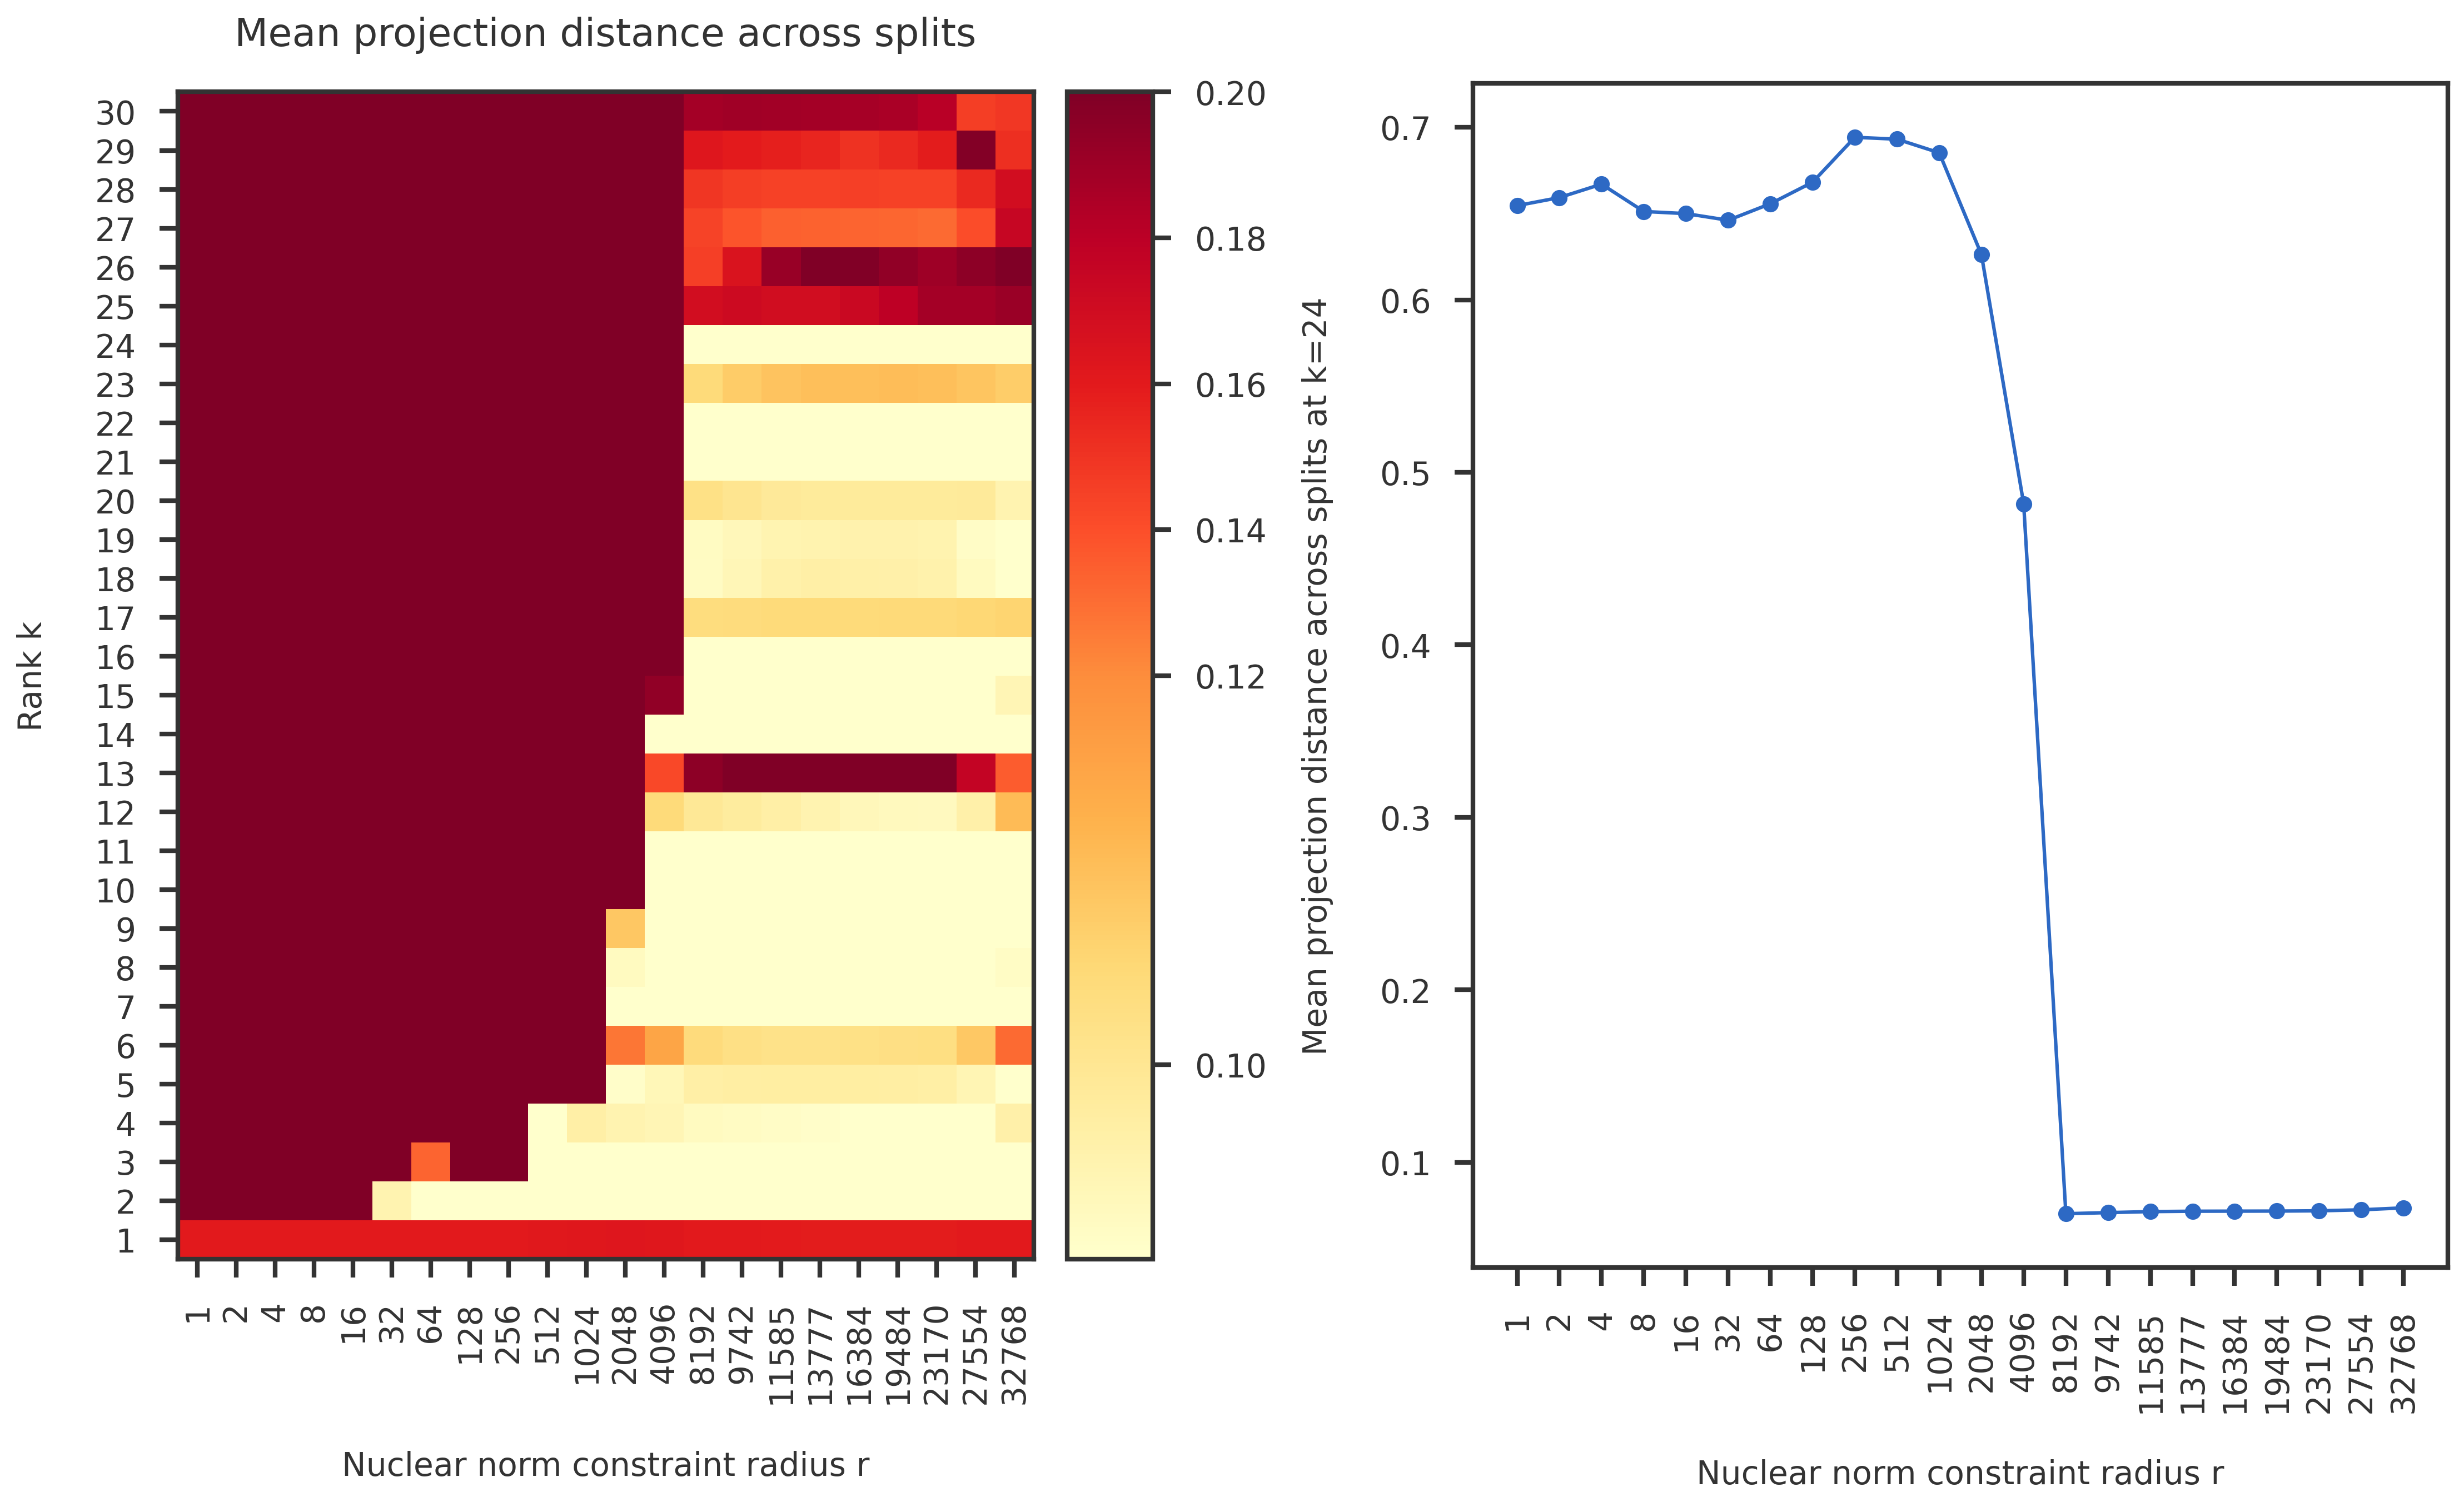

In [58]:
fig = plt.figure(figsize = (15, 9))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

def plot_heatmap(ax, X, rank_list, k_list, vmin = 0, vcenter = 0.9, vmax = 1.0):
    cmap1 = mpl_cmaps.get_cmap("YlOrRd").copy()
    cmap1.set_bad("w")
    norm1 = mpl_colors.TwoSlopeNorm(vmin = vmin, vcenter = vcenter, vmax = vmax)
    im1 = ax.imshow(X, cmap = cmap1, norm = norm1, origin = 'lower')
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="10%", pad=0.2)
    cbar = plt.colorbar(im1, cax=cax, fraction = 0.1)

    ax.set_xlabel("Nuclear norm constraint radius r")
    ax.set_ylabel("Rank k")
    ax.set_yticks(np.arange(len(k_list)))
    ax.set_yticklabels([str(int(k)) for k in k_list])
    ax.set_xticks(np.arange(len(rank_list)))
    ax.set_xticklabels([str(int(r)) for r in rank_list], rotation=90)
    
    return

rank_list = dist_df.columns.to_numpy()
k_list = dist_df.index.to_numpy()
plot_heatmap(ax1, dist_df.to_numpy(), rank_list, k_list, vmin = 0.09, vcenter = 0.12, vmax = 0.2)
ax1.set_title("Mean projection distance across splits", pad = 20)

k_choose = 24
dist_vals = dist_df.loc[k_choose].to_numpy()
ax2.plot(np.arange(len(dist_vals)), dist_vals, 'o-')
ax2.set_xlabel("Nuclear norm constraint radius r")
ax2.set_ylabel(f"Mean projection distance across splits at k={k_choose:d}")
ax2.set_xticks(np.arange(len(dist_vals)))
ax2.set_xticklabels(rank_list, rotation=90)

plt.tight_layout()
plt.show()

## Diagnostics

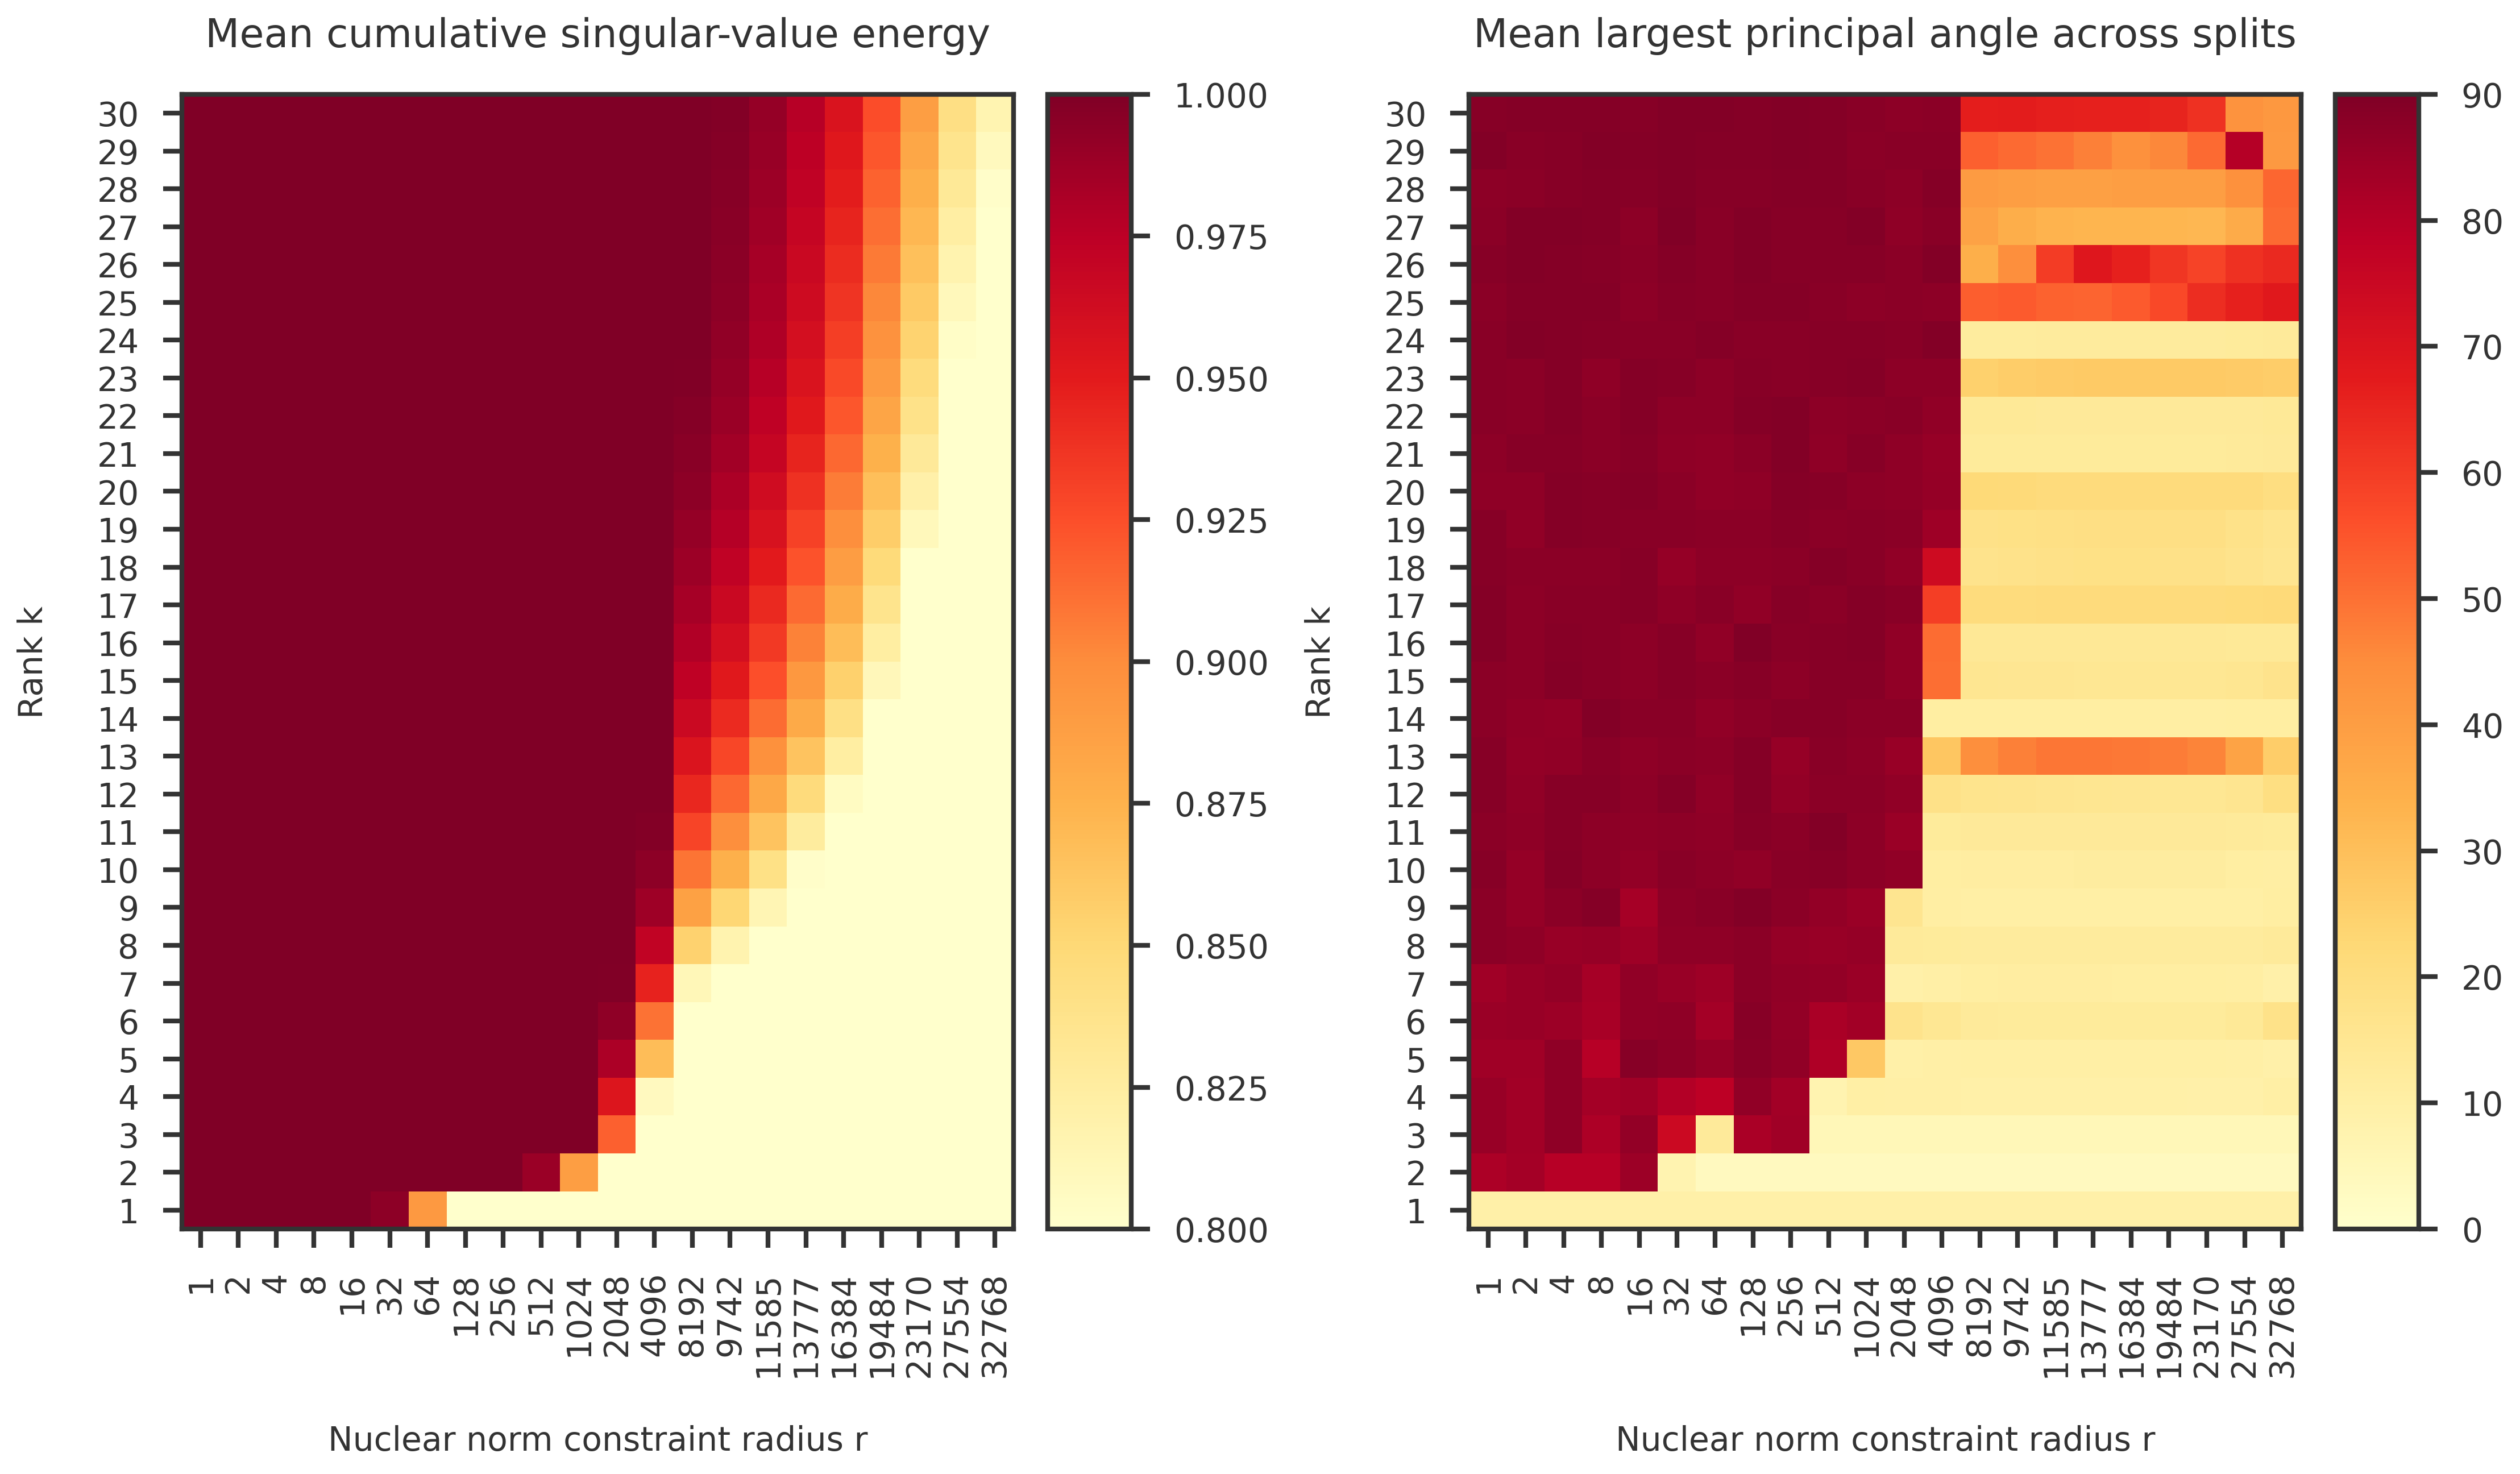

In [60]:
fig = plt.figure(figsize = (15, 9))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

plot_heatmap(ax1, energy_df.to_numpy(), rank_list, k_list, vmin = 0.8, vcenter = 0.9, vmax = 1.0)
ax1.set_title("Mean cumulative singular-value energy", pad = 20)

rank_list = gap_angle_df.columns.to_numpy()
k_list = gap_angle_df.index.to_numpy()
plot_heatmap(ax2, gap_angle_df.to_numpy(), rank_list, k_list, vmin = 0, vcenter = 45, vmax = 90.0)
ax2.set_title("Mean largest principal angle across splits", pad = 20)


plt.tight_layout()
plt.show()